In [1]:
from tradepy.target import create_targets, create_targets_atr, apply_liquidity_filter, audit_single_df, evaluate_atr_multipliers, target_realistic, target_triple_barrier_realistic
from tradepy.models import prepare_all, run_gold_master_workflow, create_lstm_dataset, apply_confidence_filter, sweep_confidence_thresholds, compute_trade_pnl
from tradepy.load import import_dataset
import numpy as np
import torch.nn as nn
import torch
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd


In [2]:
asset_list = ["bp1", "cl1", "es1", "gc1"]
ASSET = asset_list[3]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2

In [3]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Features/features_config.json")


Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388


In [11]:
info_json = pd.read_json("../Ingest/futuros_specs.json")[ASSET[:2].upper()].to_dict()

In [55]:
def basic_strat(df, rolling_window=20):
    df = df.copy()

    df["signal"] = 0

    # filtro de volatilidad
    # vol_filter = df["atr"] > df["atr"].rolling(rolling_window).quantile(0.6)
    
    cond_long = (
        (df["ema_fast"] > df["ema_slow"]) &
        (df["rsi"] > 55) &
        (df["volume_z"] > 1.5) &
        (df["ema_slow"] > df["ema_slow"].shift(5))
        )

    cond_short = (
        (df["ema_fast"] < df["ema_slow"]) &
        (df["rsi"] < 45) &
        (df["volume_z"] > 1.5) &
        (df["ema_slow"] < df["ema_slow"].shift(5))
        )
    

    # asignación vectorizada
    df.loc[cond_long, "signal"] = 1
    df.loc[cond_short, "signal"] = -1

    # evitar lookahead bias
    df["signal"] = df["signal"].shift(1)

    # stops dinámicos
    df["stop_loss"] = 1.5 * df["atr"]
    df["take_profit"] = 2.5 * df["atr"]

    return df

In [56]:
def backtest_basic(df, spec, sampling_min=1, horizon_min=120):
    """
    Unifica la lógica de señales, gestión de posición por tiempo 
    y cálculo de P&L monetario para futuros.
    """
    df = df.copy()
    
    # 1. Parámetros del Instrumento (JSON)
    tick_value = float(spec["tick_value"])      # 10.0 para GC
    tick_size = float(spec["tick_size"])        # 0.1 para GC
    fee_side = float(spec.get("approx_total_fee_per_side", 2.5))
    slip_ticks = float(spec.get("min_slippage_ticks", 1.0))
    spread_ticks = float(spec.get("min_spread_ticks", 1.0))
    
    # 2. Gestión de Posición con Barrera Vertical (Tiempo)
    # Creamos un grupo cada 'horizon_min' para resetear la posición
    horizon_bins = max(1, horizon_min // sampling_min)
    df['barrier_group'] = np.arange(len(df)) // horizon_bins
    
    # Solo mantenemos la señal si estamos dentro de la ventana de tiempo desde la señal original
    # Para simplificar vectorialmente: ffill() pero limitado por el grupo de tiempo
    df["position"] = df.groupby('barrier_group')['signal'].ffill().fillna(0)
    
    # 3. Identificación de Trades y Costes
    # Un trade ocurre cuando la posición cambia (0 -> 1, 1 -> 0, 1 -> -1, etc.)
    df["trades"] = df["position"].diff().abs().fillna(0)
    
    # Cálculo de coste total por trade en USD
    # (Comisión entrada + salida) + (Slippage + Spread en ticks convertido a dinero)
    cost_per_trade_money = (fee_side * 2) + ((slip_ticks + spread_ticks) * tick_value)
    
    # 4. Cálculo de P&L Monetario
    # P&L por vela = (Cambio de precio en ticks) * (Posición anterior) * (Valor del tick)
    df["pnl_points"] = df["close"].diff() * df["position"].shift(1)
    df["pnl_money"] = (df["pnl_points"] / tick_size) * tick_value
    
    # Restamos los costes en el momento que ocurre el trade
    df["net_pnl_money"] = df["pnl_money"] - (df["trades"] * cost_per_trade_money)
    
    # 5. Equity Curve
    initial_equity = 100000.0
    df["equity"] = initial_equity + df["net_pnl_money"].cumsum()
    
    return df

In [57]:
def backtest_complete(df, spec, sampling_min=1, horizon_min=120, sl_mult=1.5, tp_mult=2.5):
    df = df.copy()
    
    # 1. Parámetros del Instrumento
    tick_val = float(spec["tick_value"])
    tick_sz = float(spec["tick_size"])
    fee_total = (float(spec.get("approx_total_fee_per_side", 2.5)) * 2) + \
                ((float(spec.get("min_slippage_ticks", 1.0)) + float(spec.get("min_spread_ticks", 1.0))) * tick_val)

    # 2. Definir niveles de salida en el momento de la señal
    # Usamos el ATR para que el SL/TP sea dinámico según la volatilidad
    df['sl_dist'] = df['atr'] * sl_mult
    df['tp_dist'] = df['atr'] * tp_mult
    
    # 3. Lógica de Triple Barrera (Iterativa para precisión)
    # Nota: El backtest vectorial puro falla con SL/TP, usamos un bucle optimizado
    signals = df[df['signal'] != 0].index
    df['position'] = 0
    df['exit_type'] = "" # Para diagnóstico: "SL", "TP" o "Time"

    horizon_ticks = horizon_min // sampling_min
    prices = df['close'].values
    highs = df['high'].values
    lows = df['low'].values
    indices = df.index

    for idx in signals:
        sig = df.at[idx, 'signal']
        start_pos = df.index.get_loc(idx)
        sl_price = prices[start_pos] - (df.at[idx, 'sl_dist'] * sig)
        tp_price = prices[start_pos] + (df.at[idx, 'tp_dist'] * sig)
        
        # Buscamos qué barrera se toca primero en la ventana de tiempo
        end_pos = min(start_pos + horizon_ticks, len(df) - 1)
        
        for t in range(start_pos + 1, end_pos + 1):
            # Check Stop Loss
            if (sig == 1 and lows[t] <= sl_price) or (sig == -1 and highs[t] >= sl_price):
                df.loc[idx:indices[t], 'position'] = sig
                df.at[indices[t], 'exit_type'] = "SL"
                break
            # Check Take Profit
            if (sig == 1 and highs[t] >= tp_price) or (sig == -1 and lows[t] <= tp_price):
                df.loc[idx:indices[t], 'position'] = sig
                df.at[indices[t], 'exit_type'] = "TP"
                break
            # Si llegamos al final de la ventana (Tiempo)
            if t == end_pos:
                df.loc[idx:indices[t], 'position'] = sig
                df.at[indices[t], 'exit_type'] = "Time"
            
            df.loc[indices[t], 'position'] = sig

    # 4. Cálculo de P&L monetario
    df["trades"] = df["position"].diff().abs().fillna(0).clip(0, 1)
    df["pnl_money"] = (df["close"].diff() / tick_sz) * tick_val * df["position"].shift(1)
    
    # Aplicar costes: solo cuando la posición se abre
    # (En este modelo, el trade=1 indica apertura o cierre, dividimos el fee)
    df["net_pnl_money"] = df["pnl_money"] - (df["trades"] * (fee_total / 2))
    
    initial_equity = 100000.0
    df["equity"] = initial_equity + df["net_pnl_money"].cumsum()
    
    return df

In [58]:
def get_stats(df):
    total_trades = len(df[df['exit_type'] != ""])
    if total_trades == 0: return "No trades found."
    
    # Calcular Win Rate
    # Un trade es ganador si el PnL acumulado en esa ventana fue positivo
    # (Aproximación rápida para el reporte)
    wins = df[df['exit_type'] == "TP"].shape[0]
    losses = df[df['exit_type'] == "SL"].shape[0]
    times = df[df['exit_type'] == "Time"].shape[0]
    
    print(f"--- Reporte de Triple Barrera ---")
    print(f"Total Trades: {total_trades}")
    print(f"Salidas por Take Profit (TP): {wins} ({100*wins/total_trades:.2f}%)")
    print(f"Salidas por Stop Loss (SL): {losses} ({100*losses/total_trades:.2f}%)")
    print(f"Salidas por Tiempo (120m): {times} ({100*times/total_trades:.2f}%)")
    print(f"---------------------------------")

# Ejecuta esto tras tu backtest
# get_stats(df_resultado)

In [59]:
df = basic_strat(df_final)

In [48]:
df = backtest_basic(df, info_json, sampling_min=MINUTES, horizon_min=RETURN_HORIZON_MIN)

In [60]:
df = backtest_complete(df, info_json, sampling_min=MINUTES, horizon_min=RETURN_HORIZON_MIN)

In [61]:
get_stats(df)

--- Reporte de Triple Barrera ---
Total Trades: 6277
Salidas por Take Profit (TP): 232 (3.70%)
Salidas por Stop Loss (SL): 727 (11.58%)
Salidas por Tiempo (120m): 5318 (84.72%)
---------------------------------


<Axes: title={'center': 'Equity Curve - GC1 - Basic Strat'}>

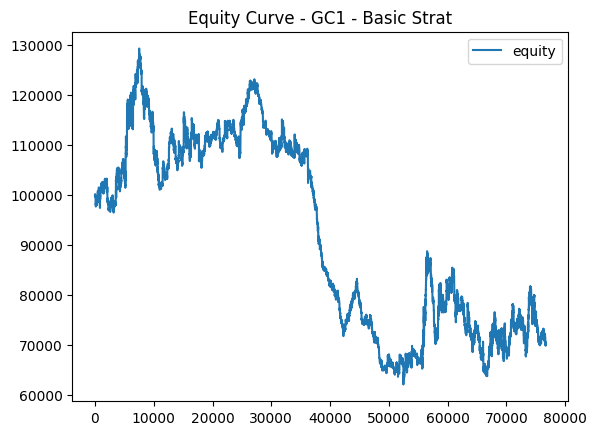

In [62]:
df.plot(y="equity", title=f"Equity Curve - {ASSET.upper()} - Basic Strat")

In [35]:
df.trades.sum()

np.float64(1057.0)